### ECE/CS/ISyE 524 &mdash; Introduction to Optimization ###

# Roommate Matching Optimization #

#### James Quinn (jfquinn2@wisc.edu), John Yuu (yuu@wisc.edu), Tessa Campbell (tncampbell@wisc.edu)
*****

### Table of Contents

1. [Introduction](#1.-Introduction)
1. [Mathematical Model](#2.-Mathematical-Model)
1. [Implementation](#3.-Implementation)
    1. [Maximization](#3A.-Maximization)
    2. [Dealbreakers](#3B.-Dealbreaker-Constraints)
    3. [MaxMin](#3C.-MaxMin)
1. [Results and Discussion](#4.-Results-and-discussion)
1. [Conclusion](#5.-Conclusion)

## 1. Introduction ##

There are many new experiences when starting college, but one that many students share and feel is out of their control is finding the right roommate. Sometimes, universities simply match roommates randomly with no criteria. Some students believe they have made the right choice either with a friend or someone they've found online, but many end up discovering that they are not as compatible with their roommate as they had initially hoped. Our project hopes to alleviate this stress by matching roommates based on their lifestyle choices. Students would be answering questions about themselves including but not limited to cleanliness, sleep habits, and noise preferences. With these answers, our project aims to match students with the goal of maximizing compatibility within each roommate pair.

Our data was collected through an online survey that prompts users to rate the importance of several categories. Survey responders were prompted to give a rating of where they would place themselves for lifestyle habits like bedtime, noise levels, and cleanliness. Each one of these habits was paired with an importance weight, indicating how rigid or flexible their routines are. This survey was sent out to friends and family, with the goal of getting a wide array of responses from people with varying preferences. This data is used to create an optimization, emphasizing the maximization of total compatibility. The questions themselves were created based on a mix of both our own desires in an ideal roommate and inspiration from other online surveys that also ask about roommate preferences. With our results, it is easily possible to expand for more preference categories or more roommate pairs.

This report will detail the solution to our problem after analyzing our sample data. The first section shows the optimal solution to maximize compatibility between roommates. Our problem variables, constraints, and objective function are all explained then used in an optimizer to guarantee the absolute best case scenario for matching. After that, we analyze the solution and explore possible changes to the problem. We then conclude this project with our insights gained and final thoughts.


## 2. Mathematical Model ##

### 2.A. Maximization

This project models a roommate matching problem as an optimization problem based on compatibility across multiple lifestyle categories. The goal is to assign students to roommates in pairs that maximize overall compatibility. 

**Decision Variables**

Define binary decision variables for students $i, j \in \{1, \ldots, n\}$, where $n$ is the total number of students:

$$
x_{ij} =
\begin{cases}
1 & \text{if student } i \text{ is matched with student } j \\
0 & \text{otherwise}
\end{cases}
$$

**Parameters**

- $C$: Set of compatibility categories (e.g., bedtime, cleanliness)  
- For each category $c \in C$ and student $i$:  
  - $p_{ic} \in \{1, \ldots, 5\}$: preference value of student $i$ for category $c$  
  - $w_{ic} \in \{1, \ldots, 5\}$: importance weight assigned by student $i$ to category $c$

**Compatibility Score**

The compatibility score between students $i$ and $j$:

$$
s_{ij} = \frac{1}{|C|} \sum_{c \in C} w_{ic} \left(5 - \lvert p_{ic} - p_{jc} \rvert \right)
$$

This multiplies the difference in their preferences by their importance to student $i$.

**Optimization Problem**

The objective is to maximize the total compatibility score across all matched pairs:

$$
\begin{aligned}
\underset{x}{\text{maximize}} \quad & \sum_{i=1}^n \sum_{j>i}^n s_{ij} x_{ij} \\
\text{subject to} \quad
& \sum_{j \ne i} x_{ij} = 1 && \forall i \in \{1, \ldots, n\} \\
& x_{ij} = x_{ji} && \forall i,j \in \{1, \ldots, n\},\ i < j \\
& x_{ii} = 0 && \forall i \in \{1, \ldots, n\} \\
& x_{ij} \in \{0,1\} && \forall i,j \in \{1, \ldots, n\}
\end{aligned}
$$

**Model Type**

This is a Mixed Integer Programming (MIP) problem. The decision variables x<sub>ij</sub> are binary, and both the objective and constraints are linear.

### 2.B. Decision Variables

The dealbreaker model uses very high weights for certain critical preferences:

- For each category $c \in C$ and student $i$:
  - If category $c$ is a dealbreaker for student $i$:
    $$w_{ic} = 10000$$
  - Otherwise:
    $$w_{ic} \in \{1, \ldots, 5\}$$

The compatibility score calculation becomes:

$$
s_{ij} = \frac{1}{|C|} \sum_{c \in C} \min(w_{ic}, 5) \left(5 - \lvert p_{ic} - p_{jc} \rvert \right)
$$

The objective function and constraints are the same, but the high weights force the optimizer to prioritize satisfying dealbreaker preferences over other factors.

### 2.C. MaxMin Optimization

The MaxMin model changes the optimization problem to maximize the minimum compatibility score across all matches, ensuring fairness in the matching process:

**Additional Variable**
- Let $z$ represent the minimum compatibility score across all matches

**Modified Optimization Problem**

$$
\begin{aligned}
\underset{x,z}{\text{maximize}} \quad & z \\
\text{subject to} \quad
& z \leq s_{ij} + M(1-x_{ij}) && \forall i,j \in \{1, \ldots, n\},\ i < j \\
& \sum_{j \ne i} x_{ij} = 1 && \forall i \in \{1, \ldots, n\} \\
& x_{ij} = x_{ji} && \forall i,j \in \{1, \ldots, n\},\ i < j \\
& x_{ii} = 0 && \forall i \in \{1, \ldots, n\} \\
& x_{ij} \in \{0,1\} && \forall i,j \in \{1, \ldots, n\}
\end{aligned}
$$

$M$ is a large constant (1000). The first constraint ensures that $z$ is less than or equal to the compatibility score of every matched pair. Pairs that are not matched always satisfy the constraint due to the large M. By maximizing $z$, the model finds a matching where the lowest compatibility score is as high as possible which ensures that no single match has a significantly lower compatiblity score than the others.

## 3. Implementation ##

This code implements the optimization for matching compatible roommates. There are 12 categories considered in the matching: sleep schedule (bedtime and wake up time), cleanliness standards, smoking habits, alcohol consumption, pets, noise tolerance, frequency of guests, number of guests, how close they want to be to their roommate, willingness to share items, and how often they are in the apartment. Each person rates their own habits (1-5) for each category then rates how important each category is to them. 



### 3A. Maximization

The algorithm calculates compatibility scores between all pairs of students, taking into account their habits and weighting (importance). It maximizes the overall compatibility of all matches. 

The code also performs sensitivity analysis to see how much changing an answer in each category would affect the overall compatibility score to see which factors have the strongest impact on compatibility.

In [1]:
using JuMP, GLPK

# Categories
categories = ["bedtime", "awake", "cleanliness", "smoking", "alcohol", "pets", "noise", 
            "guests_freq", "guests_num", "closeness", "sharing", "time_in_apt"]

# Number of students
n_students = 20

# Student indices
students = 1:n_students

# Data arrays for each category
bedtime = [3,2,4,4,4,5,4,4,3,3,4,5,3,3,3,3,4,1,5,1]
awake = [2,1,3,3,4,4,3,3,3,3,3,4,2,2,3,2,4,1,1,1]
cleanliness = [1,5,4,4,2,3,4,4,4,5,3,4,4,4,3,3,3,5,2,1]
smoking = [5,1,3,1,2,4,5,4,3,1,5,3,2,5,3,5,1,1,5,1]
alcohol = [5,1,2,3,5,5,5,4,2,3,4,4,5,4,5,5,3,1,4,4]
pets = [1,1,5,5,4,5,5,5,5,4,5,4,4,5,5,5,1,2,4,5]
noise = [5,1,3,3,3,2,3,2,3,2,4,4,3,3,3,4,3,1,4,2]
guests_freq = [5,1,3,5,4,4,5,2,4,2,5,4,3,4,4,4,3,4,5,5]
guests_num = [5,0,3,5,5,5,5,1,3,1,5,5,3,5,4,3,3,2,1,5]
closeness = [1,1,5,5,4,4,5,4,5,4,5,5,3,3,4,4,4,3,3,4]
sharing = [5,1,3,4,3,3,1,3,4,2,2,4,2,4,2,5,2,2,1,5]
time_in_apt = [5,5,2,2,4,4,3,3,4,3,3,4,4,4,3,4,4,3,5,1]

# Importance weights for each category
weights = Dict(
    "bedtime" => [1,1,4,3,3,4,3,3,2,1,4,3,2,2,2,1,3,5,5,5],
    "awake" => [4,4,2,2,3,2,2,2,2,2,2,1,4,4,2,2,2,2,2,2],
    "cleanliness" => [3,5,4,5,2,3,5,4,5,5,2,3,4,5,2,2,2,5,2,2],
    "smoking" => [5,5,3,5,4,4,4,4,2,5,4,1,2,4,2,4,5,5,5,5],
    "alcohol" => [5,5,1,1,3,5,5,3,4,1,1,2,4,3,4,5,1,5,2,2],
    "pets" => [5,5,4,5,2,3,3,4,2,2,3,3,2,2,3,2,5,4,2,3],
    "noise" => [5,5,1,1,1,1,1,2,2,2,3,3,2,1,1,2,1,5,3,4],
    "guests_freq" => [2,5,2,5,5,5,5,3,2,3,4,4,3,4,3,3,3,3,4,4],
    "guests_num" => [5,5,2,5,3,3,3,5,3,5,5,5,2,5,3,2,2,2,5,4],
    "closeness" => [5,5,4,4,2,2,4,2,5,2,4,4,1,1,3,2,2,2,1,2],
    "sharing" => [4,5,2,2,2,3,5,1,2,4,4,2,4,2,4,3,3,3,5,4],
    "time_in_apt" => [5,4,3,3,4,3,2,3,4,2,1,2,3,4,2,3,3,4,2,4]
)

# Store all preferences
preferences = Dict(
    "bedtime" => bedtime,
    "awake" => awake,
    "cleanliness" => cleanliness,
    "smoking" => smoking,
    "alcohol" => alcohol,
    "pets" => pets,
    "noise" => noise,
    "guests_freq" => guests_freq,
    "guests_num" => guests_num,
    "closeness" => closeness,
    "sharing" => sharing,
    "time_in_apt" => time_in_apt
)

m = Model()

# Variable: x[i,j] = 1 if student i is matched with student j
@variable(m, x[students,students], Bin)

# Calculate compatibility score
function calculate_score(i, j)
    score = 0.0
    for cat in categories
        # Get preferences for this category
        prefs = preferences[cat]
        # Get weights for both students
        w_i = weights[cat][i]
        w_j = weights[cat][j]
        # Calculate average weight
        avg_weight = (w_i + w_j) / 2
        # Calculate total score using average weight
        score += (5 - abs(prefs[i] - prefs[j])) * avg_weight
    end
    # Calculate average score
    return score / length(categories)
end

# Objective: Maximize total compatibility score
@objective(m, Max, sum(calculate_score(i,j) * x[i,j] for i in students, j in students if i < j))

# Each student must be matched with exactly one other student
for i in students
    @constraint(m, sum(x[i,j] for j in students if j != i) == 1)
end

# No self-matching
for i in students
    @constraint(m, x[i,i] == 0)
end

# Symmetry constraint
for i in students
    for j in students
        # Avoid double counting pairs
        if i < j
            @constraint(m, x[i,j] == x[j,i])
        end
    end
end

set_optimizer(m, GLPK.Optimizer)
optimize!(m)

# Store the optimal solution
optimal_solution = value.(x)

# Print results
println("ROOMMATE MATCHES AND COMPATIBILITY SCORES:")
println("----------------------------------------")
println("Pairing\t\t\tTotal Compatibility Score")
println("----------------------------------------")

for i in students
    for j in students
        if i < j && optimal_solution[i,j] > 0.5
            score = calculate_score(i, j)
            println("Student$i ↔ Student$j\t\t$(round(score, digits=2))")
        end
    end
end

println("\nTotal matches: $(sum(optimal_solution[i,j] for i in students, j in students if i < j))")

# Calculate and print average compatibility score
total_score = 0.0
match_count = 0
for i in students
    for j in students
        if i < j && optimal_solution[i,j] > 0.5
            score = calculate_score(i, j)
            total_score += score
            match_count += 1
        end
    end
end
avg_score = total_score / match_count
println("\nAverage compatibility score: $(round(avg_score, digits=2))")

# Sensitivity Analysis
println("\nSENSITIVITY ANALYSIS")
println("-------------------")
println("\nImpact on matching quality if preferences increase by 1 point:")
println("(Positive = improvement, Negative = decline, Magnitude = strength of effect)\n")

# Store total impacts for each category
category_impacts = Dict{String, Float64}()
category_counts = Dict{String, Int}()
for cat in categories
    category_impacts[cat] = 0.0
    category_counts[cat] = 0
end

# Calculate impacts for each student and category
for cat in categories
    for i in students
        # Current preference value for category
        current_value = preferences[cat][i]
        # Only analyze if preference can increase
        if current_value < 5 
            impact = 0
            count = 0
            # Calculate impact for each potential pairing
            for j in students
                # Only consider students that were matched
                if i != j && optimal_solution[i,j] > 0.5
                    # Get weights
                    weight = weights[cat][i]
                    # Calculate difference in preferences
                    old_diff = abs(current_value - preferences[cat][j])
                    # Calculate new difference if preference increased by 1
                    new_diff = abs(current_value + 1 - preferences[cat][j])
                    # Calculate impact on compatibility score
                    impact += weight * ((5 - new_diff) - (5 - old_diff))
                    count += 1
                end
            end
            # Only add to total if there are compatible pairings
            if count > 0
                category_impacts[cat] += impact
                category_counts[cat] += 1
            end
        end
    end
end

# Print average impacts by category
println("\nAverage Impact Across All Students by Category:")
println("--------------------------------------------")
for cat in categories
    if category_counts[cat] > 0
        avg_impact = category_impacts[cat] / category_counts[cat]
        println("$cat: $(round(avg_impact, digits=2))")
    end
end 

ROOMMATE MATCHES AND COMPATIBILITY SCORES:
----------------------------------------
Pairing			Total Compatibility Score
----------------------------------------
Student1 ↔ Student16		12.79
Student2 ↔ Student18		16.83
Student3 ↔ Student9		12.79
Student4 ↔ Student20		13.75
Student5 ↔ Student6		13.54
Student7 ↔ Student11		15.38
Student8 ↔ Student19		11.29
Student10 ↔ Student17		10.79
Student12 ↔ Student14		12.54
Student13 ↔ Student15		11.62

Total matches: 10.0

Average compatibility score: 13.13

SENSITIVITY ANALYSIS
-------------------

Impact on matching quality if preferences increase by 1 point:
(Positive = improvement, Negative = decline, Magnitude = strength of effect)


Average Impact Across All Students by Category:
--------------------------------------------
bedtime: -0.18
awake: -1.0
cleanliness: -1.47
smoking: -2.14
alcohol: -2.08
pets: 2.0
noise: -0.79
guests_freq: -0.71
guests_num: -0.73
closeness: -0.14
sharing: -0.88
time_in_apt: -0.47



### 3B. Dealbreaker Constraints

Some of the categories were marked as "dealbreakers" that must be met (i.e. if no smoking is a dealbreaker, the roommate matched must not smoke). This code takes those dealbreakers into account by weighting the dealbreakers with very high importance. The functionality is otherwise the same as the above code (maximizing total compatibility)

In [2]:
using JuMP, GLPK

# Categories
categories = ["bedtime", "awake", "cleanliness", "smoking", "alcohol", "pets", "noise", 
            "guests_freq", "guests_num", "closeness", "sharing", "time_in_apt"]

# Number of students
n_students = 20

# Student indices
students = 1:n_students

# Data arrays for each category
bedtime = [3,2,4,4,4,5,4,4,3,3,4,5,3,3,3,3,4,1,5,1]
awake = [2,1,3,3,4,4,3,3,3,3,3,4,2,2,3,2,4,1,1,1]
cleanliness = [1,5,4,4,2,3,4,4,4,5,3,4,4,4,3,3,3,5,2,1]
smoking = [5,1,3,1,2,4,5,4,3,1,5,3,2,5,3,5,1,1,5,1]
alcohol = [5,1,2,3,5,5,5,4,2,3,4,4,5,4,5,5,3,1,4,4]
pets = [1,1,5,5,4,5,5,5,5,4,5,4,4,5,5,5,1,2,4,5]
noise = [5,1,3,3,3,2,3,2,3,2,4,4,3,3,3,4,3,1,4,2]
guests_freq = [5,1,3,5,4,4,5,2,4,2,5,4,3,4,4,4,3,4,5,5]
guests_num = [5,0,3,5,5,5,5,1,3,1,5,5,3,5,4,3,3,2,1,5]
closeness = [1,1,5,5,4,4,5,4,5,4,5,5,3,3,4,4,4,3,3,4]
sharing = [5,1,3,4,3,3,1,3,4,2,2,4,2,4,2,5,2,2,1,5]
time_in_apt = [5,5,2,2,4,4,3,3,4,3,3,4,4,4,3,4,4,3,5,1]

# Importance weights for each category
# Dealbreakers are implemented by setting very high weights (10000)
weights = Dict(
    "bedtime" => [1,1,4,3,3,4,3,3,2,1,4,3,2,2,2,1,3,5,5,5],
    "awake" => [4,4,2,2,3,2,2,2,2,2,2,1,4,4,2,2,2,2,2,2],
    "cleanliness" => [3,5,4,5,2,3,5,4,5,5,2,3,4,5,2,2,2,5,2,2],
    "smoking" => [5,10000,3,5,4,4,4,4,2,5,4,1,2,4,2,4,5,5,5,5],
    "alcohol" => [5,10000,1,1,3,5,5,3,4,1,1,2,4,3,4,5,1,5,2,2],  
    "pets" => [5,5,4,5,2,3,3,4,2,2,3,3,2,2,3,2,10000,4,2,3],    
    "noise" => [5,5,1,1,1,1,1,2,2,2,3,3,2,1,1,2,1,5,3,4],
    "guests_freq" => [2,5,2,5,5,5,5,3,2,3,4,4,3,4,3,3,3,3,4,4],
    "guests_num" => [5,5,2,5,3,3,3,5,3,5,5,5,2,5,3,2,2,2,5,4],
    "closeness" => [10000,5,4,4,2,2,4,2,5,2,4,4,1,1,3,2,2,2,1,2],
    "sharing" => [4,5,2,2,2,3,5,1,2,4,4,2,4,2,4,3,3,3,5,4],
    "time_in_apt" => [5,4,3,3,4,3,2,3,4,2,1,2,3,4,2,3,3,4,2,4]
)

# Store all preferences
preferences = Dict(
    "bedtime" => bedtime,
    "awake" => awake,
    "cleanliness" => cleanliness,
    "smoking" => smoking,
    "alcohol" => alcohol,
    "pets" => pets,
    "noise" => noise,
    "guests_freq" => guests_freq,
    "guests_num" => guests_num,
    "closeness" => closeness,
    "sharing" => sharing,
    "time_in_apt" => time_in_apt
)

m = Model()

# Variable: x[i,j] = 1 if student i is matched with student j
@variable(m, x[students,students], Bin)

# Calculate compatibility score
# Third argument is true if the score is being calculated for optimization or for finding compatibility score
# For optimization, use the original weights (10000 for dealbreakers)
# For finding the compatibility score, cap the weights at 5
function calculate_score(i, j, for_optimization=true)
    score = 0.0
    for cat in categories
        # Get preferences for this category
        prefs = preferences[cat]
        # Get weights for both students
        w_i = weights[cat][i]
        w_j = weights[cat][j]
        
        if for_optimization
            # For optimization: use max weight to ensure dealbreakers are used
            weight = max(w_i, w_j)
        else
            # For display: cap weights at 5 and use average
            capped_w_i = min(w_i, 5)
            capped_w_j = min(w_j, 5)
            weight = (capped_w_i + capped_w_j) / 2
        end
        
        # Calculate score for this category
        score += (5 - abs(prefs[i] - prefs[j])) * weight
    end
    # Calculate average score
    return score / length(categories)
end

# Objective: Maximize total compatibility score
@objective(m, Max, sum(calculate_score(i,j,true) * x[i,j] for i in students, j in students if i < j))

# Each student must be matched with exactly one other student
for i in students
    @constraint(m, sum(x[i,j] for j in students if j != i) == 1)
end

# No self-matching
for i in students
    @constraint(m, x[i,i] == 0)
end

# Symmetry constraint
for i in students
    for j in students
        # Avoid double counting pairs
        if i < j
            @constraint(m, x[i,j] == x[j,i])
        end
    end
end

set_optimizer(m, GLPK.Optimizer)
optimize!(m)

# Store the optimal solution
optimal_solution = value.(x)

# Print results
println("ROOMMATE MATCHES AND COMPATIBILITY SCORES:")
println("----------------------------------------")
println("Pairing\t\t\tTotal Compatibility Score")
println("----------------------------------------")

for i in students
    for j in students
        if i < j && optimal_solution[i,j] > 0.5
            score = calculate_score(i, j, false)
            println("Student$i ↔ Student$j\t\t$(round(score, digits=2))")
        end
    end
end

println("\nTotal matches: $(sum(optimal_solution[i,j] for i in students, j in students if i < j))")

# Calculate and print average compatibility score
total_score = 0.0
match_count = 0
for i in students
    for j in students
        if i < j && optimal_solution[i,j] > 0.5
            score = calculate_score(i, j, false)
            total_score += score
            match_count += 1
        end
    end
end
avg_score = total_score / match_count
println("\nAverage compatibility score: $(round(avg_score, digits=2))")

# Sensitivity Analysis
println("\nSENSITIVITY ANALYSIS")
println("-------------------")
println("\nImpact on matching quality if preferences increase by 1 point:")
println("(Positive = improvement, Negative = decline, Magnitude = strength of effect)\n")

# Store total impacts for each category
category_impacts = Dict{String, Float64}()
category_counts = Dict{String, Int}()
for cat in categories
    category_impacts[cat] = 0.0
    category_counts[cat] = 0
end

# Calculate impacts for each student and category
for cat in categories
    for i in students
        # Current preference value for category
        current_value = preferences[cat][i]
        # Only analyze if preference can increase
        if current_value < 5 
            impact = 0
            count = 0
            # Calculate impact for each potential pairing
            for j in students
                # Only consider students that were matched
                if i != j && optimal_solution[i,j] > 0.5
                    # Cap weights at 5 for sensitivity analysis
                    weight = min(weights[cat][i], 5)  
                    # Calculate difference in preferences
                    old_diff = abs(current_value - preferences[cat][j])
                    # Calculate new difference if preference increased by 1
                    new_diff = abs(current_value + 1 - preferences[cat][j])
                    # Calculate impact on compatibility score
                    impact += weight * ((5 - new_diff) - (5 - old_diff))
                    count += 1
                end
            end
            # Only add to total if there are compatible pairings
            if count > 0
                category_impacts[cat] += impact
                category_counts[cat] += 1
            end
        end
    end
end

# Print average impacts by category
println("\nAverage Impact Across All Students by Category:")
println("--------------------------------------------")
for cat in categories
    if category_counts[cat] > 0
        avg_impact = category_impacts[cat] / category_counts[cat]
        println("$cat: $(round(avg_impact, digits=2))")
    end
end 

ROOMMATE MATCHES AND COMPATIBILITY SCORES:
----------------------------------------
Pairing			Total Compatibility Score
----------------------------------------
Student1 ↔ Student17		10.04
Student2 ↔ Student18		16.83
Student3 ↔ Student9		12.79
Student4 ↔ Student20		13.75
Student5 ↔ Student15		11.75
Student6 ↔ Student12		13.0
Student7 ↔ Student11		15.38
Student8 ↔ Student10		12.29
Student13 ↔ Student19		10.38
Student14 ↔ Student16		12.5

Total matches: 10.0

Average compatibility score: 12.87

SENSITIVITY ANALYSIS
-------------------

Impact on matching quality if preferences increase by 1 point:
(Positive = improvement, Negative = decline, Magnitude = strength of effect)


Average Impact Across All Students by Category:
--------------------------------------------
bedtime: -0.53
awake: -1.4
cleanliness: -0.88
smoking: -1.29
alcohol: -0.69
pets: -0.67
noise: -1.11
guests_freq: -1.57
guests_num: -0.18
closeness: -0.14
sharing: 1.0
time_in_apt: -0.71


### 3C. MaxMin

This code implements a maxmin algorithm to optimize roommate compatibility (maximizes the minimum compatiblity score by finding matches where the lowest compatibility score is as high as possible). This ensures fairness by making sure that no one score is significantly worse than the others. 

In [3]:
using JuMP, GLPK

# Categories
categories = ["bedtime", "awake", "cleanliness", "smoking", "alcohol", "pets", "noise", 
            "guests_freq", "guests_num", "closeness", "sharing", "time_in_apt"]

# Number of students
n_students = 20

# Student indices
students = 1:n_students

# Data arrays for each category
bedtime = [3,2,4,4,4,5,4,4,3,3,4,5,3,3,3,3,4,1,5,1]
awake = [2,1,3,3,4,4,3,3,3,3,3,4,2,2,3,2,4,1,1,1]
cleanliness = [1,5,4,4,2,3,4,4,4,5,3,4,4,4,3,3,3,5,2,1]
smoking = [5,1,3,1,2,4,5,4,3,1,5,3,2,5,3,5,1,1,5,1]
alcohol = [5,1,2,3,5,5,5,4,2,3,4,4,5,4,5,5,3,1,4,4]
pets = [1,1,5,5,4,5,5,5,5,4,5,4,4,5,5,5,1,2,4,5]
noise = [5,1,3,3,3,2,3,2,3,2,4,4,3,3,3,4,3,1,4,2]
guests_freq = [5,1,3,5,4,4,5,2,4,2,5,4,3,4,4,4,3,4,5,5]
guests_num = [5,0,3,5,5,5,5,1,3,1,5,5,3,5,4,3,3,2,1,5]
closeness = [1,1,5,5,4,4,5,4,5,4,5,5,3,3,4,4,4,3,3,4]
sharing = [5,1,3,4,3,3,1,3,4,2,2,4,2,4,2,5,2,2,1,5]
time_in_apt = [5,5,2,2,4,4,3,3,4,3,3,4,4,4,3,4,4,3,5,1]

# Importance weights for each category
weights = Dict(
    "bedtime" => [1,1,4,3,3,4,3,3,2,1,4,3,2,2,2,1,3,5,5,5],
    "awake" => [4,4,2,2,3,2,2,2,2,2,2,1,4,4,2,2,2,2,2,2],
    "cleanliness" => [3,5,4,5,2,3,5,4,5,5,2,3,4,5,2,2,2,5,2,2],
    "smoking" => [5,5,3,5,4,4,4,4,2,5,4,1,2,4,2,4,5,5,5,5],
    "alcohol" => [5,5,1,1,3,5,5,3,4,1,1,2,4,3,4,5,1,5,2,2],
    "pets" => [5,5,4,5,2,3,3,4,2,2,3,3,2,2,3,2,5,4,2,3],
    "noise" => [5,5,1,1,1,1,1,2,2,2,3,3,2,1,1,2,1,5,3,4],
    "guests_freq" => [2,5,2,5,5,5,5,3,2,3,4,4,3,4,3,3,3,3,4,4],
    "guests_num" => [5,5,2,5,3,3,3,5,3,5,5,5,2,5,3,2,2,2,5,4],
    "closeness" => [5,5,4,4,2,2,4,2,5,2,4,4,1,1,3,2,2,2,1,2],
    "sharing" => [4,5,2,2,2,3,5,1,2,4,4,2,4,2,4,3,3,3,5,4],
    "time_in_apt" => [5,4,3,3,4,3,2,3,4,2,1,2,3,4,2,3,3,4,2,4]
)

# Store all preferences
preferences = Dict(
    "bedtime" => bedtime,
    "awake" => awake,
    "cleanliness" => cleanliness,
    "smoking" => smoking,
    "alcohol" => alcohol,
    "pets" => pets,
    "noise" => noise,
    "guests_freq" => guests_freq,
    "guests_num" => guests_num,
    "closeness" => closeness,
    "sharing" => sharing,
    "time_in_apt" => time_in_apt
)

m = Model()

# Variable: x[i,j] = 1 if student i is matched with student j
@variable(m, x[students,students], Bin)

# Minimum compatibility score
@variable(m, min_score)

# Calculate compatibility score
function calculate_score(i, j)
    score = 0.0
    for cat in categories
        # Get preferences for this category
        prefs = preferences[cat]
        # Get weights for both students
        w_i = weights[cat][i]
        w_j = weights[cat][j]
        # Calculate average weight
        avg_weight = (w_i + w_j) / 2
        # Calculate total score using average weight
        score += (5 - abs(prefs[i] - prefs[j])) * avg_weight
    end
    # Calculate average score
    return score / length(categories)
end

# Objective: Maximize the minimum compatibility score
@objective(m, Max, min_score)

# Define a large constant M for the big-M method
M = 1000

# Constraint: min_score must be less than or equal to the score of any active match
for i in students
    for j in students
        if i < j
            score = calculate_score(i, j)
            @constraint(m, min_score <= score + M*(1 - x[i,j]))
        end
    end
end

# Each student must be matched with exactly one other student
for i in students
    @constraint(m, sum(x[i,j] for j in students if j != i) == 1)
end

# No self-matching
for i in students
    @constraint(m, x[i,i] == 0)
end

# Symmetry constraint
for i in students
    for j in students
        # Avoid double counting pairs
        if i < j
            @constraint(m, x[i,j] == x[j,i])
        end
    end
end

set_optimizer(m, GLPK.Optimizer)
optimize!(m)

# Store the optimal solution
optimal_solution = value.(x)
min_compatibility = value(min_score)

# Print results
println("ROOMMATE MATCHES AND COMPATIBILITY SCORES:")
println("----------------------------------------")
println("Pairing\t\t\tTotal Compatibility Score")
println("----------------------------------------")

for i in students
    for j in students
        if i < j && optimal_solution[i,j] > 0.5
            score = calculate_score(i, j)
            println("Student$i ↔ Student$j\t\t$(round(score, digits=2))")
        end
    end
end

println("\nTotal matches: $(sum(optimal_solution[i,j] for i in students, j in students if i < j))")

println("\nMinimum compatibility score across all matches: $(round(min_compatibility, digits=2))")

# Calculate and print average compatibility score
total_score = 0.0
match_count = 0
for i in students
    for j in students
        if i < j && optimal_solution[i,j] > 0.5
            score = calculate_score(i, j, false)
            total_score += score
            match_count += 1
        end
    end
end
avg_score = total_score / match_count
println("\nAverage compatibility score: $(round(avg_score, digits=2))")

# Sensitivity Analysis
println("\nSENSITIVITY ANALYSIS")
println("-------------------")
println("\nImpact on matching quality if preferences increase by 1 point:")
println("(Positive = improvement, Negative = decline, Magnitude = strength of effect)\n")

# Store total impacts for each category
category_impacts = Dict{String, Float64}()
category_counts = Dict{String, Int}()
for cat in categories
    category_impacts[cat] = 0.0
    category_counts[cat] = 0
end

# Calculate impacts for each student and category
for cat in categories
    for i in students
        # Current preference value for category
        current_value = preferences[cat][i]
        # Only analyze if preference can increase
        if current_value < 5 
            impact = 0
            count = 0
            # Calculate impact for each potential pairing
            for j in students
                # Only consider students that were matched
                if i != j && optimal_solution[i,j] > 0.5
                    # Get weights
                    weight = weights[cat][i]
                    # Calculate difference in preferences
                    old_diff = abs(current_value - preferences[cat][j])
                    # Calculate new difference if preference increased by 1
                    new_diff = abs(current_value + 1 - preferences[cat][j])
                    # Calculate impact on compatibility score
                    impact += weight * ((5 - new_diff) - (5 - old_diff))
                    count += 1
                end
            end
            # Only add to total if there are compatible pairings
            if count > 0
                category_impacts[cat] += impact
                category_counts[cat] += 1
            end
        end
    end
end

# Print average impacts by category
println("\nAverage Impact Across All Students by Category:")
println("--------------------------------------------")
for cat in categories
    if category_counts[cat] > 0
        avg_impact = category_impacts[cat] / category_counts[cat]
        println("$cat: $(round(avg_impact, digits=2))")
    end
end 

ROOMMATE MATCHES AND COMPATIBILITY SCORES:
----------------------------------------
Pairing			Total Compatibility Score
----------------------------------------
Student1 ↔ Student16		12.79
Student2 ↔ Student17		12.21
Student3 ↔ Student8		12.12
Student4 ↔ Student20		13.75
Student5 ↔ Student6		13.54
Student7 ↔ Student19		12.67
Student9 ↔ Student12		12.04
Student10 ↔ Student18		13.38
Student11 ↔ Student15		12.12
Student13 ↔ Student14		12.0

Total matches: 10.0

Minimum compatibility score across all matches: 12.0

Average compatibility score: 12.66

SENSITIVITY ANALYSIS
-------------------

Impact on matching quality if preferences increase by 1 point:
(Positive = improvement, Negative = decline, Magnitude = strength of effect)


Average Impact Across All Students by Category:
--------------------------------------------
bedtime: -0.18
awake: -1.2
cleanliness: -1.94
smoking: -2.14
alcohol: 1.0
pets: 0.67
noise: 0.26
guests_freq: -0.57
guests_num: 2.18
closeness: 0.57
sharing: -1.82
time_i

## 4. Results and discussion ##

Below, we have compiled all the tables for easy viewing, as well as a summary table.

<table>
<tr><th>Maximization </th><th>Dealbreaker Constraints </th><th>MaxMin</th></tr>
<tr><td>

| Roommate 1        | Roommate 2           | Compatibility  |
|:-----------------:|:--------------------:|:--------------:|
| Student 1         | Student 16           | 12.79          |
| Student 2         | Student 18           | 16.83          |
| Student 3         | Student 9            | 12.79          |
| Student 4         | Student 20           | 13.75          |
| Student 5         | Student 6            | 13.54          |
| Student 7         | Student 11           | 15.38          |
| Student 8         | Student 19           | 11.29          |
| Student 10        | Student 17           | 10.79          |
| Student 12        | Student 14           | 12.54          |
| Student 13        | Student 15           | 11.62          |

</td><td>

| Roommate 1        | Roommate 2           | Compatibility  |
|:-----------------:|:--------------------:|:--------------:|
| Student 1         | Student 17           | 10.04          |
| Student 2         | Student 18           | 16.83          |
| Student 3         | Student 9            | 12.79          |
| Student 4         | Student 20           | 13.75          |
| Student 5         | Student 15           | 11.75          |
| Student 6         | Student 12           | 13.00          |
| Student 7         | Student 11           | 15.38          |
| Student 8         | Student 10           | 12.29          |
| Student 13        | Student 19           | 10.38          |
| Student 14        | Student 16           | 12.50          |

</td><td>

| Roommate 1        | Roommate 2           | Compatibility  |
|:-----------------:|:--------------------:|:--------------:|
| Student 1         | Student 16           | 12.79          |
| Student 2         | Student 17           | 12.21          |
| Student 3         | Student 8            | 12.12          |
| Student 4         | Student 20           | 13.75          |
| Student 5         | Student 6            | 13.54          |
| Student 7         | Student 19           | 12.67          |
| Student 9         | Student 12           | 12.04          |
| Student 10        | Student 18           | 13.38          |
| Student 11        | Student 15           | 12.12          |
| Student 13        | Student 14           | 12.00          |

</td></tr> </table>

<table>
<tr><th>Summary </th></tr>
<tr><td>

| Statistic         | Maximization     | Dealbreaker Constraints  | MaxMin         |
|:-----------------:|:----------------:|:------------------------:|:--------------:|
| Minimum           | 10.79            | 10.04                    | 12.00          |
| Maximum           | 16.83            | 16.83                    | 13.75          |
| Range             | 6.04             | 6.79                     | 1.75           |
| Mean              | 13.132           | 12.871                   | 12.662         |
| Standard Dev.     | 1.7614           | 1.9676                   | 0.6406         |
| 1st quartile      | 11.62            | 11.75                    | 12.12          |
| Median            | 12.79            | 12.645                   | 12.44          |
| 3rd quartile      | 13.75            | 13.75                    | 13.38          |
| IQR               | 2.13             | 2.00                     | 1.26           |

</td></tr> </table>

A higher score indicates a better match.

The first observation that can easily be made is the row indicating minimum compatibility. MaxMin was specifically designed to maximize the minimum compatibility, so this would be the best option if we wanted to be fair (ensuring everyone is at least somewhat happy with their roommates). MaxMin also has the smallest range, so each roommate pair would be similarly compatible. Including dealbreakers causes every statistic to be either the same as or worse than simple maximization. However, this may be a necessary evil to ensure happiness amongst the roommates. In some cases, dealbreakers can be crucial (i.e. no pets due to allergies).

It's worth noting here that not every statistic can be directly compared between 3b (Dealbreaker Constraints) and the other two - the weights were changed when the dealbreaker constraints were added in 3b, and removed for 3c. (The compatability scores for any pairs which remained the same did also remain the same, but that was because they would have already been an exact match in the relevant categories if they were still getting matched when dealbreakers were introduced).
However, 3a (Maximization) and 3c (MaxMin) can be compared without restraint.

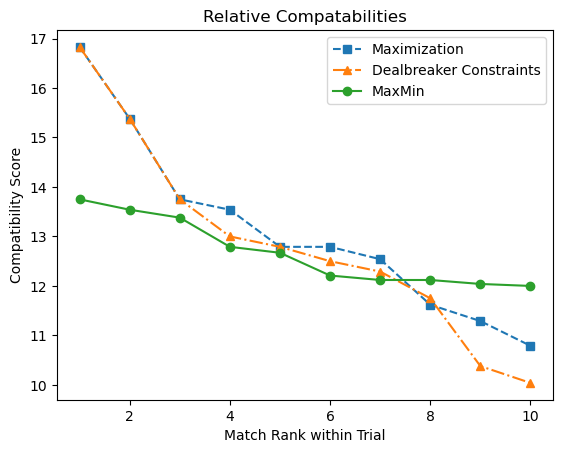

In [4]:
using PyPlot

# 3 lists of compatability scores
Maximization = [12.79, 16.83, 12.79, 13.75, 13.54, 15.38, 11.29, 10.79, 12.54, 11.62]
Dealbreaker = [10.04, 16.83, 12.79, 13.75, 11.75, 13.00, 15.38, 12.29, 10.38, 12.50]
MaxMin = [12.79, 12.21, 12.12, 13.75, 13.54, 12.67, 12.04, 13.38, 12.12, 12.00]

# Sort each list
sortedMax = sort(Maximization, rev=true)
sortedDeal = sort(Dealbreaker, rev=true)
sortedMM = sort(MaxMin, rev=true)

# Plot
plot(1:10, sortedMax, label="Maximization", linestyle="--", marker="s")
plot(1:10, sortedDeal, label="Dealbreaker Constraints", linestyle="-.", marker="^")
plot(1:10, sortedMM, label="MaxMin", linestyle="-", marker="o")

xlabel("Match Rank within Trial")
ylabel("Compatibility Score")
title("Relative Compatabilities")
legend()
grid(false)

### Maximization vs Dealbreaker Constraints
Although it would be unwise to directly compare the mean and median of the Maximization trial to the trial with Dealbreaker Constraints, we can notice the overall trend shown in the graph. While the dealbreaker constraints do lead to some slightly worse matches in the middle of the pack, they really struggle with the bottom end of matches. The bottom two matches with dealbreaker constraints were signifcantly worse than those without dealbreaker constraints. Obviously, one should not just simply ignore the dealbreaker constraints and use the Maximization model, but perhaps an approach trying to mitigate those bottom results could be wise.


### The Impact of a Dealbreaker
Students 1 and 16 were paired together with a fairly average compatability score of 12.79. They were a decent match overall, however, one of the categories they did not match on was listed as a dealbreaker by one of them (Student 1 really did not want to be close with their roommate). Thus, Student 1 needed a new match, which ended up getting a far worse score of 10.04 (the worst match of all). However, if this was truly a dealbreaker for the student, this would be a better match, despite the lower score.


### The MaxMin Tradeoff
In the standard maximization and in the dealbreaker constraints trial, students 2 and 18 were matched with an incredible score of 16.83. This was the best score of any match in any trial. However, they were split up for the MaxMin trial, as they both ended up going with others that were struggling to find a good match, especially Student 2. They were paired with Student 17 in the MaxMin, who had previously been a part of the lowest scoring match in both trials.

The objective becomes somewhat of an ethics question here - how much do you want to prioritize equity in matches as opposed to the greatest total compatability. Other factors at play would likely contribute to this decision, such as how easy it is for a student to switch rooms if their pairing is not working out. For example, in the fall of 2020, when students had less ability to connect outside of their roommate, and switching rooms may have been signifcantly harder than normal, the MaxMin approach could be valuable to mitigate damages.


### The Consistent Match
While some respondents had different pairs throughout, or at least split 2/1, there was one pair that remained constant - students 4 and 20.

<table>
<tr><th>Summary </th></tr>
<tr><td>

| Category           | Student 4        | Student 20               |
|:------------------:|:----------------:|:------------------------:|
| Bedtime            | 12am-2am         | 6pm-8pm                  |
| Wake-up            | 8am-10am         | 4am-6am                  |
| Cleanliness        | 4/5              | 1/5                      |
| Smoking            | 1/5              | 1/5                      |
| Alcohol            | 3/5              | 4/5                      |
| Pets               | 5/5              | 5/5                      |
| Noise              | 3/5              | 2/5                      |
| Guests (frequency) | 5/5              | 5/5                      |
| Guests (amount)    | 5/5              | 5/5                      |
| Friendliness       | 5/5              | 4/5                      |
| Borrowing          | 4/5              | 5/5                      |
| Time in Room       | 2/5              | 1/5                      |


</td></tr> </table>

Although they were matched in every pairing, they were not always the best match. However, they were both unideal matches for other students, and as every student needed a roommate, they ended up matched every time.

Student 20 was one of the most unique respondents. They were one of only two to put a 6pm-8pm bedtime, and one of only three to put a 4am-6am wakeup. However, they were not matched with this, as they clashed on most every other preference. It could be argued, however, that sleeping habits are one of the most important things to be in sync with a roommate for, however it was not something anyone put as a dealbreaker.

With such a small amount of students, it was hard to make everyone happy in every regard. A university matching thousands of students would likely be able to find far better matches for most students.

## 5. Conclusion ##

Our findings showed that figuring out statistical compatibility is possible and can be shifted based on what our goals are. It's a bit unfortunate that these are all hypothetical, since we did not have the option of asking our survey responders to actually live together and test our results. 

There are many ways to expand on this project and its findings. One interesting route to take would be simply introducing one more person to the pool while keeping the number of rooms the same. This introduces more complexity by creating a situation where there is one group of three. The pairings may shift only slightly, the new person may fit perfectly with an existing pair, or the entire problem may change drastically to move people around to keep compatibility high. The decision variables would shift, forcing the variables x<sub>ij</sub> to allow for a third, but only for one of the pairs. The parameters and objective function (maximizing compatibility) would stay the same. Another similar expansion could be a scenario in which you have one additional room - thus two people would get their own room. This would likely allow two of the most unique individuals to be by themselves, and allow the rest of the pairs to have better compatability scores.

As mentioned previously, this problem becomes easier with scale. With a larger number of students, there is a greater chance that each student will have a good match. A full university would also likely have more constraints - in addition to more survey questions, there would likely be multiple dorms, which students would likely have preferences and/or requirements for.

## 6. Author Contributions


#### 1. Modelling  
James: Percentage contribution 25%  
John:  Percentage contribution 50%  
Tessa: Percentage contribution 25%  

  
#### 2. Analysis  
James: Percentage contribution 50%  
John:  Percentage contribution 30%  
Tessa: Percentage contribution 20%  


#### 3. Data Gathering  
James: Percentage contribution 33.33%  
John:  Percentage contribution 33.33%  
Tessa: Percentage contribution 33.33%  


#### 4. Software Implementation  
James: Percentage contribution 10%  
John:  Percentage contribution 10%  
Tessa: Percentage contribution 80%  


#### 5. Report Writing    
James: Percentage contribution 50%  
John:  Percentage contribution 40%  
Tessa: Percentage contribution 10%  